In [1]:
#Importações

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from Apoio.config import DADOS_LIMPOS
from Apoio.graficos import SCATTER_ALPHA, PALETTE

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(palette="bright", style="white")

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_income_cat,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.23,37.88,41,880,129,322,126,8.3252,452600,NEAR BAY,5,6.984127,2.555556,0.146591
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500,NEAR BAY,5,6.238137,2.109842,0.155797
2,-122.26,37.84,42,2555,665,1206,595,2.0804,226700,NEAR BAY,2,4.294118,2.026891,0.260274
3,-122.26,37.85,50,1120,283,697,264,2.1250,140000,NEAR BAY,2,4.242424,2.640152,0.252679
4,-122.26,37.84,50,2239,455,990,419,1.9911,158700,NEAR BAY,2,5.343675,2.362768,0.203216


In [3]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_income_cat,rooms_per_household,population_per_household,bedrooms_per_room
17559,-121.09,39.48,25,1665,374,845,330,1.5603,78100,INLAND,2,5.045455,2.560606,0.224625
17560,-121.21,39.49,18,697,150,356,114,2.5568,77100,INLAND,2,6.114035,3.122807,0.215208
17561,-121.22,39.43,17,2254,485,1007,433,1.7000,92300,INLAND,2,5.205543,2.325635,0.215173
17562,-121.32,39.43,18,1860,409,741,349,1.8672,84700,INLAND,2,5.329513,2.123209,0.219892
17563,-121.24,39.37,16,2785,616,1387,530,2.3886,89400,INLAND,2,5.254717,2.616981,0.221185


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17564 entries, 0 to 17563
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 17564 non-null  float64 
 1   latitude                  17564 non-null  float64 
 2   housing_median_age        17564 non-null  int8    
 3   total_rooms               17564 non-null  int16   
 4   total_bedrooms            17564 non-null  int16   
 5   population                17564 non-null  int16   
 6   households                17564 non-null  int16   
 7   median_income             17564 non-null  float64 
 8   median_house_value        17564 non-null  int32   
 9   ocean_proximity           17564 non-null  category
 10  median_income_cat         17564 non-null  int64   
 11  rooms_per_household       17564 non-null  float64 
 12  population_per_household  17564 non-null  float64 
 13  bedrooms_per_room         17564 non-null  floa

#### Criando uma visualização entre longitude e latitude

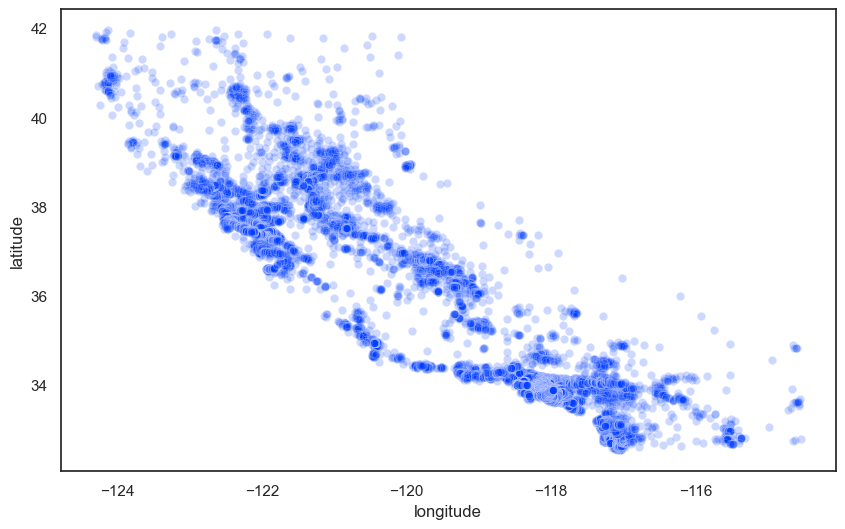

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df, x="longitude", y="latitude", alpha=SCATTER_ALPHA)

plt.show()

O gráfico possui a forma clara do estado da Califórnia, sendo praticamente um mapa de pontos.

Podemos notar alta concentração no litoral e aglomerados urbanos.

O interior é mais disperso.

Não há **correlação** real, não existindo uma relação do tipo quanto maior a longitude, maior a latitude.

#### Criação de um jointplot entre longitude e latitude

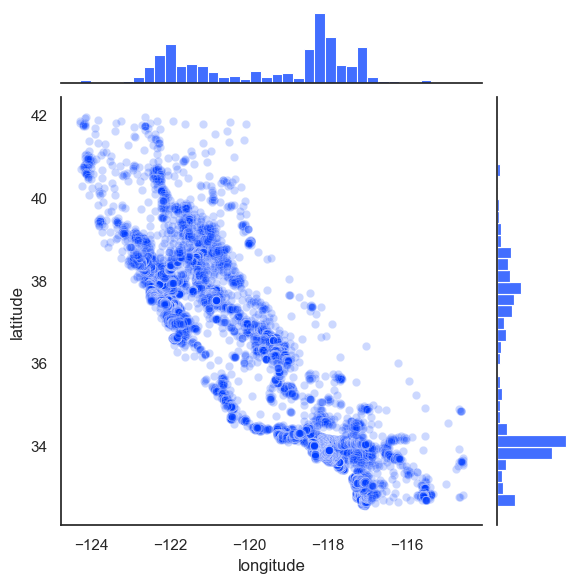

In [6]:
sns.jointplot(data=df, x="longitude", y="latitude", alpha=SCATTER_ALPHA)

Os dados são altamente concentrados em regiões específicas, não espalhados uniformemente.

Distribuição das coordenadas.

Identificação de regiões com mais dados.

Evidência clara de clusters (agrupamentos) urbanos.

#### Criando uma visualização entre longitude e latitude, mas usando ocean_proximity (proximidade com o oceano) como categoria

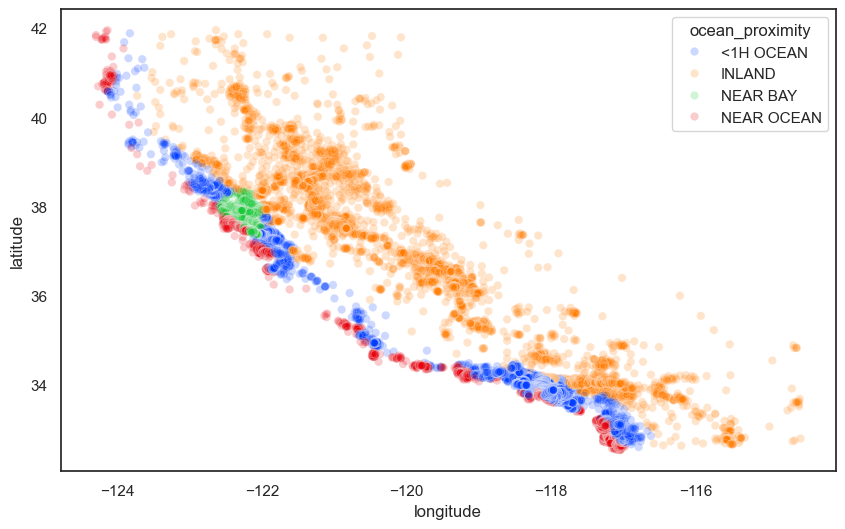

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df, x="longitude", y="latitude", alpha=SCATTER_ALPHA, hue="ocean_proximity")

plt.show()

#### Criando uma visualização entre longitude e latitude, mas usando median_income_cat (renda média categórica) como categoria

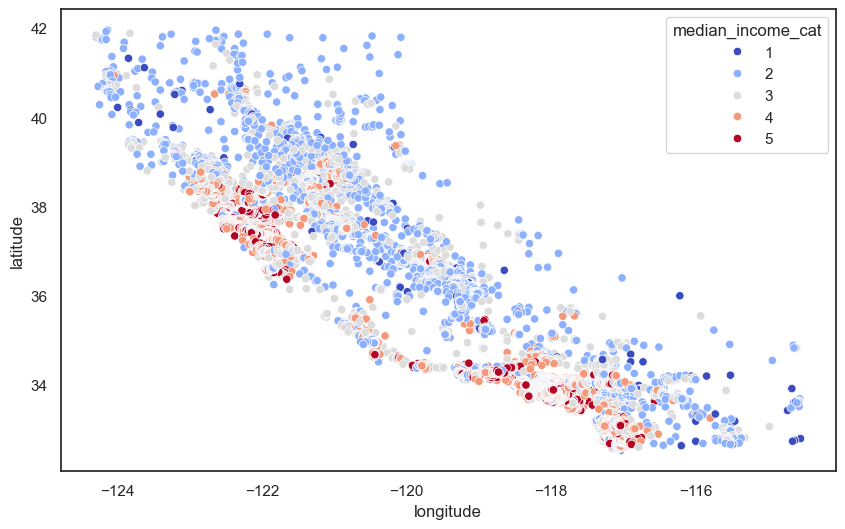

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df, x="longitude", y="latitude", alpha=1, hue="median_income_cat", palette=PALETTE)

plt.show()

Podemos observar, que as maiores rendas médias, estão concentradas no litoral ou próximo dele. Por outro lado, a renda mais baixa está concentrada em sua maioria no interior.

Mesmo sem plotar preço, dá para inferir que:
- Regiões vermelhas -> casas mais caras
- Regiões azuis -> casas mais baratas

#### Criando uma visualização entre longitude e latitude, mas usando median_house_value (valor médio da casa) como categoria

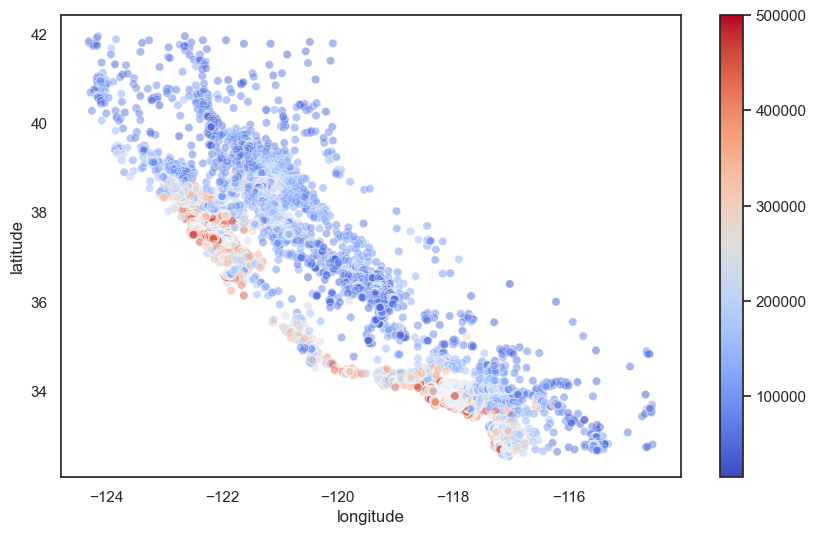

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

normalize_median_house_value = plt.Normalize(df["median_house_value"].min(), df["median_house_value"].max())
SC_norm_median_house_value = plt.cm.ScalarMappable(norm=normalize_median_house_value, cmap=PALETTE)

sns.scatterplot(data=df, x="longitude", y="latitude", alpha=1/2, hue="median_house_value", palette=PALETTE)

ax.get_legend().remove()
fig.colorbar(SC_norm_median_house_value, ax=ax)

plt.show()

Pudemos confirmar o que foi observado no gráfico anterior, regiões vermelhas indicam casas mais caras, enquanto regiões azuis indicam casas mais baratas.